# Three Reasoning Benchmarks Demo: Math, Knowledge, Science

This notebook demonstrates the **reasoning benchmark dataset** — a standardized collection of three complementary reasoning tasks from HuggingFace Hub:

- **GSM8K** (openai/gsm8k): Grade-school arithmetic word problems requiring 2-8 step reasoning
- **MMLU** (cais/mmlu): Multiple-choice questions spanning 57 subjects across STEM/social sciences/humanities
- **ARC-Challenge** (allenai/ai2_arc): Multiple-choice grade-school science reasoning questions

All three datasets are standardized into a unified schema with rich metadata for difficulty stratification and evaluation.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger

# Configure logging for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-1464a1-taylors-power-law-for-llm-error-clusteri/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    """Load data from GitHub URL with local fallback."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception as e:
        logger.debug(f"GitHub fetch failed: {e}, trying local file")
    
    if Path("mini_demo_data.json").exists():
        with open("mini_demo_data.json") as f:
            return json.load(f)
    
    raise FileNotFoundError("Could not load mini_demo_data.json from GitHub or local path")

In [4]:
data = load_data()
logger.info(f"Loaded data: {len(data['datasets'])} datasets")

17:27:43|INFO   |Loaded data: 3 datasets


## Configuration

All tunable parameters are set to MINIMUM values for quick execution. Increase as needed for full analysis.

In [5]:
# Tunable parameters — start with minimum values
MAX_EXAMPLES_PER_DATASET = 3  # Show all examples from mini dataset
TRUNCATE_TEXT_AT = 100  # Truncate input/output text in displays
PLOT_FIGSIZE = (12, 4)  # Figure size for plots

## Data Structure Overview

The data is organized as a top-level object with:
- `metadata`: dataset source and benchmark IDs
- `datasets`: array of dataset entries, each with `dataset` name and `examples` array

Each example contains:
- `input`: question/prompt text
- `output`: ground-truth answer
- `metadata_*`: rich metadata fields (row index, task type, lengths, dataset-specific fields)

In [6]:
# Display metadata
metadata = data['metadata']
print("\n=== Data Metadata ===")
print(f"Source: {metadata['source']}")
print(f"Description: {metadata['description']}")
print("\nBenchmark IDs:")
for name, desc in metadata['benchmark_ids'].items():
    print(f"  {name}: {desc}")


=== Data Metadata ===
Source: HuggingFace Hub
Description: Six reasoning benchmarks standardized to unified schema for difficulty-stratification research

Benchmark IDs:
  gsm8k: openai/gsm8k (config=main, split=test)
  mmlu: cais/mmlu (config=all, split=test)
  arc_challenge: allenai/ai2_arc (config=ARC-Challenge, split=test)
  hellaswag: Rowan/hellaswag (split=validation)
  commonsense_qa: tau/commonsense_qa (split=validation)
  openbookqa: allenai/openbookqa (config=main, split=test)


## Dataset Examples

Display a few representative examples from each dataset to show the structure and task types.

In [7]:
for dataset_info in data['datasets']:
    dataset_name = dataset_info['dataset']
    examples = dataset_info['examples'][:MAX_EXAMPLES_PER_DATASET]
    
    print(f"\n{'='*80}")
    print(f"Dataset: {dataset_name.upper()} ({len(dataset_info['examples'])} total examples)")
    print(f"{'='*80}")
    
    for i, example in enumerate(examples, 1):
        print(f"\n--- Example {i} ---")
        task_type = example.get('metadata_task_type', 'unknown')
        print(f"Task Type: {task_type}")
        
        # Input
        input_text = example['input']
        if len(input_text) > TRUNCATE_TEXT_AT:
            input_text = input_text[:TRUNCATE_TEXT_AT] + "..."
        print(f"\nInput (first {TRUNCATE_TEXT_AT} chars):\n{input_text}")
        
        # Output
        print(f"\nOutput: {example['output']}")
        
        # Metadata fields (excluding input/output/full_solution)
        metadata_fields = {k: v for k, v in example.items() 
                          if k.startswith('metadata_') and k != 'metadata_full_solution'}
        if metadata_fields:
            print("\nMetadata:")
            for key, value in sorted(metadata_fields.items()):
                if isinstance(value, list):
                    if len(str(value)) > TRUNCATE_TEXT_AT:
                        value = str(value)[:TRUNCATE_TEXT_AT] + "..."
                print(f"  {key}: {value}")


Dataset: GSM8K (3 total examples)

--- Example 1 ---
Task Type: free_response_math

Input (first 100 chars):
Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for ...

Output: 18

Metadata:
  metadata_question_length_chars: 280
  metadata_reasoning_steps: 2
  metadata_row_index: 0
  metadata_task_type: free_response_math

--- Example 2 ---
Task Type: free_response_math

Input (first 100 chars):
A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it ...

Output: 3

Metadata:
  metadata_question_length_chars: 105
  metadata_reasoning_steps: 2
  metadata_row_index: 1
  metadata_task_type: free_response_math

--- Example 3 ---
Task Type: free_response_math

Input (first 100 chars):
Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repai...

Output: 70000

Metadata:
  metadata_question_length_chars: 181
  metadata_reasoning_steps: 4
  metadata_row_index: 2

## Quantitative Analysis

Summary statistics across the three datasets: example counts, task types, and metadata distributions.

In [8]:
# Build analysis table
rows = []
for dataset_info in data['datasets']:
    dataset_name = dataset_info['dataset']
    examples = dataset_info['examples']
    
    n_examples = len(examples)
    
    # Task types
    task_types = {}
    for ex in examples:
        tt = ex.get('metadata_task_type', 'unknown')
        task_types[tt] = task_types.get(tt, 0) + 1
    
    task_types_str = ', '.join(f"{k}({v})" for k, v in sorted(task_types.items()))
    
    # Input/output lengths
    avg_input_len = np.mean([len(ex['input']) for ex in examples])
    avg_output_len = np.mean([len(ex['output']) for ex in examples])
    
    rows.append({
        'Dataset': dataset_name,
        'Examples': n_examples,
        'Task Types': task_types_str,
        'Avg Input Length': f"{avg_input_len:.0f}",
        'Avg Output Length': f"{avg_output_len:.0f}",
    })

df = pd.DataFrame(rows)
print("\n=== Dataset Summary Statistics ===")
print(df.to_string(index=False))

total_examples = sum(len(ds['examples']) for ds in data['datasets'])
print(f"\nTotal examples across all datasets: {total_examples}")


=== Dataset Summary Statistics ===
      Dataset  Examples            Task Types Avg Input Length Avg Output Length
        gsm8k         3 free_response_math(3)              189                 3
         mmlu         3     classification(3)              116                 1
arc_challenge         3     classification(3)              349                 1

Total examples across all datasets: 9


## Metadata Distributions

Detailed breakdown of metadata fields by dataset, showing reasoning complexity (e.g., steps) and question characteristics.

In [9]:
for dataset_info in data['datasets']:
    dataset_name = dataset_info['dataset']
    examples = dataset_info['examples']
    
    print(f"\n{'='*60}")
    print(f"Metadata Details: {dataset_name.upper()}")
    print(f"{'='*60}")
    
    # Collect all unique metadata keys
    all_keys = set()
    for ex in examples:
        all_keys.update(k for k in ex.keys() if k.startswith('metadata_') and k != 'metadata_full_solution')
    
    # For each metadata key, show values
    for key in sorted(all_keys):
        values = [ex.get(key) for ex in examples]
        
        # Skip list values (like metadata_choice_texts)
        if any(isinstance(v, list) for v in values):
            print(f"\n{key}: [list fields - {len(values)} examples]")
            continue
        
        # Check if numeric
        try:
            numeric_values = [float(v) for v in values if v is not None]
            if numeric_values:
                print(f"\n{key}:")
                print(f"  min: {min(numeric_values):.2f}, max: {max(numeric_values):.2f}, mean: {np.mean(numeric_values):.2f}")
            else:
                print(f"\n{key}: {set(v for v in values if v is not None)}")
        except (TypeError, ValueError):
            # Non-numeric scalar values
            unique_vals = set(str(v) for v in values if v is not None)
            if len(unique_vals) <= 5:
                print(f"\n{key}: {unique_vals}")
            else:
                print(f"\n{key}: {len(unique_vals)} unique values")


Metadata Details: GSM8K

metadata_question_length_chars:
  min: 105.00, max: 280.00, mean: 188.67

metadata_reasoning_steps:
  min: 2.00, max: 4.00, mean: 2.67

metadata_row_index:
  min: 0.00, max: 2.00, mean: 1.00

metadata_task_type: {'free_response_math'}

Metadata Details: MMLU

metadata_choice_texts: [list fields - 3 examples]

metadata_n_classes:
  min: 4.00, max: 4.00, mean: 4.00

metadata_question_length_chars:
  min: 65.00, max: 130.00, mean: 92.67

metadata_row_index:
  min: 0.00, max: 2.00, mean: 1.00

metadata_subject: {'abstract_algebra'}

metadata_task_type: {'classification'}

Metadata Details: ARC_CHALLENGE

metadata_choice_texts: [list fields - 3 examples]

metadata_n_classes:
  min: 4.00, max: 4.00, mean: 4.00

metadata_problem_id: {'Mercury_7175875', 'Mercury_SC_408547', 'Mercury_SC_409171'}

metadata_question_length_chars:
  min: 138.00, max: 279.00, mean: 185.33

metadata_row_index:
  min: 0.00, max: 2.00, mean: 1.00

metadata_task_type: {'classification'}


## Visualization: Question Lengths and Dataset Sizes

Visual comparison of datasets by example count and question complexity (character length).

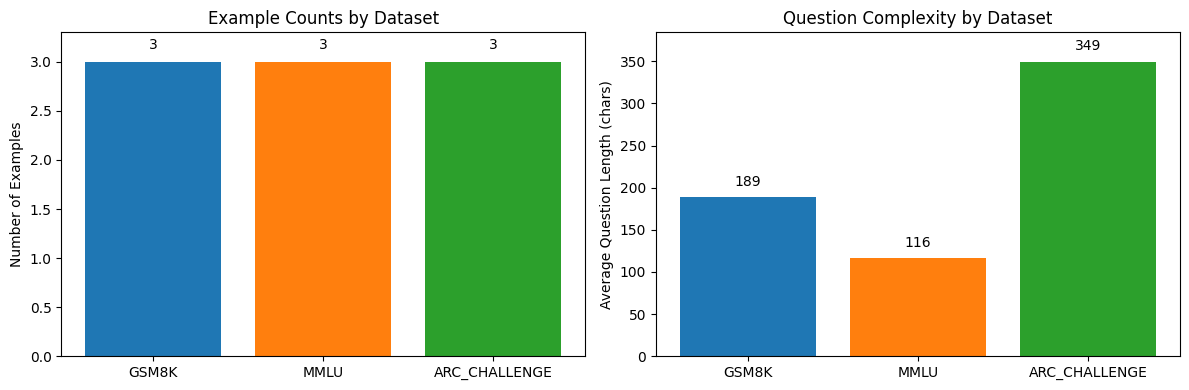


Figure: Dataset sizes and complexity metrics


In [10]:
fig, axes = plt.subplots(1, 2, figsize=PLOT_FIGSIZE)

# Left: Example counts by dataset
dataset_names = []
example_counts = []
for dataset_info in data['datasets']:
    dataset_names.append(dataset_info['dataset'].upper())
    example_counts.append(len(dataset_info['examples']))

axes[0].bar(dataset_names, example_counts, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('Number of Examples')
axes[0].set_title('Example Counts by Dataset')
axes[0].set_ylim(0, max(example_counts) * 1.1)
for i, (name, count) in enumerate(zip(dataset_names, example_counts)):
    axes[0].text(i, count + 0.1, str(count), ha='center', va='bottom')

# Right: Average question length by dataset
avg_lengths = []
for dataset_info in data['datasets']:
    avg_len = np.mean([len(ex['input']) for ex in dataset_info['examples']])
    avg_lengths.append(avg_len)

axes[1].bar(dataset_names, avg_lengths, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Average Question Length (chars)')
axes[1].set_title('Question Complexity by Dataset')
axes[1].set_ylim(0, max(avg_lengths) * 1.1)
for i, (name, length) in enumerate(zip(dataset_names, avg_lengths)):
    axes[1].text(i, length + 10, f"{length:.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nFigure: Dataset sizes and complexity metrics")

## Summary

This demo notebook loaded and explored the **reasoning benchmark dataset** containing:

1. **GSM8K**: Free-response math problems with step-by-step solutions and numeric answers
2. **MMLU**: Multiple-choice questions spanning 57 academic subjects
3. **ARC-Challenge**: Multiple-choice grade-school science reasoning questions

All examples are standardized with:
- Unified `input`/`output` schema
- Rich metadata fields for stratification (row index, task type, question length, reasoning steps, etc.)
- Dataset-specific metadata (subjects for MMLU, solution steps for GSM8K, etc.)

The dataset is ready for downstream tasks:
- Difficulty stratification via metadata
- Model evaluation with known ground truths
- Error analysis and reasoning complexity studies

**Next steps**: Load the full dataset, sample by difficulty, and run model inference or power-law analysis.

In [11]:
print("\n" + "="*60)
print("Demo Complete")
print("="*60)
print(f"Loaded {len(data['datasets'])} datasets with {total_examples} total examples")
print(f"Each example has input, output, and rich metadata for analysis")
print(f"\nData loading pattern (GitHub + local fallback):")
print(f"  GITHUB_DATA_URL = \"{GITHUB_DATA_URL}\"")
print(f"\nTo use the full dataset, replace mini_demo_data.json with full_data_out.json")


Demo Complete
Loaded 3 datasets with 9 total examples
Each example has input, output, and rich metadata for analysis

Data loading pattern (GitHub + local fallback):
  GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-1464a1-taylors-power-law-for-llm-error-clusteri/main/round-1/dataset-1/demo/mini_demo_data.json"

To use the full dataset, replace mini_demo_data.json with full_data_out.json
